# Exploration: Missions
**MISSION DATA**

---

**Zweck:** Die Einsatzdaten (`Mission_Data`) durchleuchten: Aufbau, Lücken, Verteilungen, Kategorien.  
**Input:** `raw_mission_data` (Bronze) und `stg_missions` (typisiert, 1:1 zur Quelle) aus `data/berlin_emergency.duckdb`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen der Quelle; offene Fragen für `02_preparation` und `03_analysis_*`.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

Die Rohtabelle hat bewusst nur `VARCHAR`-Spalten. Für die Profilierung nutzen wir `stg_missions`: dort wird nur typisiert und umbenannt, es gehen keine Zeilen verloren (wird unten geprüft).

## Structure

### Rows per Year

In [2]:
df_years = q("""
    select _partition as year, count(*) as missions, min(mission_date) as first_day, max(mission_date) as last_day
    from raw_mission_data group by 1 order by 1
""")
show_df(df_years)
n_raw = q('select count(*) as n from raw_mission_data')['n'][0]
n_stg = q('select count(*) as n from stg_missions')['n'][0]
success(f'raw = stg: {n_raw == n_stg}  ({n_raw:,} rows)') if n_raw == n_stg else warn(f'raw {n_raw:,} != stg {n_stg:,}')

,year,missions,first_day,last_day
0,2018,463684,2018-01-01,2018-12-31
1,2019,472638,2019-01-01,2019-12-31
2,2020,466774,2020-01-01,2020-12-31
3,2021,489860,2021-01-01,2021-12-31
4,2022,526743,2022-01-01,2022-12-31
5,2023,512885,2023-01-01,2023-12-31
6,2024,532575,2024-01-01,2024-12-31
7,2025,556864,2025-01-01,2025-12-31
8,2026,439179,2026-01-01,2026-10-07


✓  raw = stg: True  (4,461,202 rows)


### Columns

In [3]:
df_cols = q("describe stg_missions")[['column_name', 'column_type']]
df_example = q("select * from stg_missions limit 3").T.reset_index()
df_example.columns = ['column_name', 'example_1', 'example_2', 'example_3']
show_df(df_cols.merge(df_example, on='column_name'))

,column_name,column_type,example_1,example_2,example_3
0,mission_date,DATE,2018-01-01 00:00:00,2018-01-03 00:00:00,2018-01-02 00:00:00
1,mission_type,VARCHAR,Rettungsdienst,Rettungsdienst,Technische Hilfeleistung
2,dispatchcode,VARCHAR,None,None,None
3,dispatch_criticality,VARCHAR,None,None,None
4,district_name,VARCHAR,Neukölln,Tempelhof-Schöneberg,Tempelhof-Schöneberg
5,response_time_seconds,INTEGER,413,633,580
6,units_non_berlin_involved,BOOLEAN,False,False,False
7,units_several_involved,BOOLEAN,False,False,False
8,units_reinforcements_called,BOOLEAN,False,False,False
9,units_organisations,VARCHAR,ORG_DRK,ORG_BFW,ORG_BFW


### Sample for Profiling

Die Profil-Funktionen von `wgnd` laufen im Speicher. Statt 4,4 Mio. Zeilen zu laden, ziehen wir eine feste Zufallsstichprobe (`reservoir`, Seed 42). Alle Zahlen zu Anteilen und Jahren kommen weiter per SQL aus der Gesamtmenge.

In [4]:
df_eda = q("select * from stg_missions using sample reservoir(200000 rows) repeatable (42)")
inspect(df_eda, sections=['dimensions', 'dtypes'])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,200000,
1,columns,17,
2,duplicates,93,0.05%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  DTYPES  ─────────────────────────────────────────────────


,column,dtype,missing_cnt,missing_pct,unique,unique_pct
0,mission_date,datetime64[us],0,0.00%,3202,1.60%
1,mission_type,str,0,0.00%,8,0.00%
2,dispatchcode,str,19545,9.77%,64,0.03%
3,dispatch_criticality,str,19545,9.77%,6,0.00%
4,district_name,str,0,0.00%,12,0.01%
5,response_time_seconds,Int32,23389,11.69%,1796,0.90%
6,units_non_berlin_involved,bool,0,0.00%,2,0.00%
7,units_several_involved,bool,0,0.00%,2,0.00%
8,units_reinforcements_called,bool,0,0.00%,2,0.00%
9,units_organisations,str,0,0.00%,132,0.07%


## Missing Values

In [5]:
inspect_missing(df_eda, chart=None)


───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,response_time_seconds,23389,11.69%
1,dispatchcode,19545,9.77%
2,dispatch_criticality,19545,9.77%
3,units_first_type,3376,1.69%


,column,missing_cnt,missing_pct
0,response_time_seconds,23389,11.69
1,dispatchcode,19545,9.77
2,dispatch_criticality,19545,9.77
3,units_first_type,3376,1.69


### Missing Response Time

`response_time_seconds` ist die Zielgröße. Fehlt sie zufällig oder systematisch? Anteil fehlender Werte nach Jahr, Einsatztyp und Dispatch-Stufe (SQL auf der Gesamtmenge).

,year,missions,pct_missing
0,2018,463684,10.40%
1,2019,472638,9.80%
2,2020,466774,11.60%
3,2021,489860,11.70%
4,2022,526743,14.40%
5,2023,512885,12.50%
6,2024,532575,11.30%
7,2025,556864,11.50%
8,2026,439179,11.60%


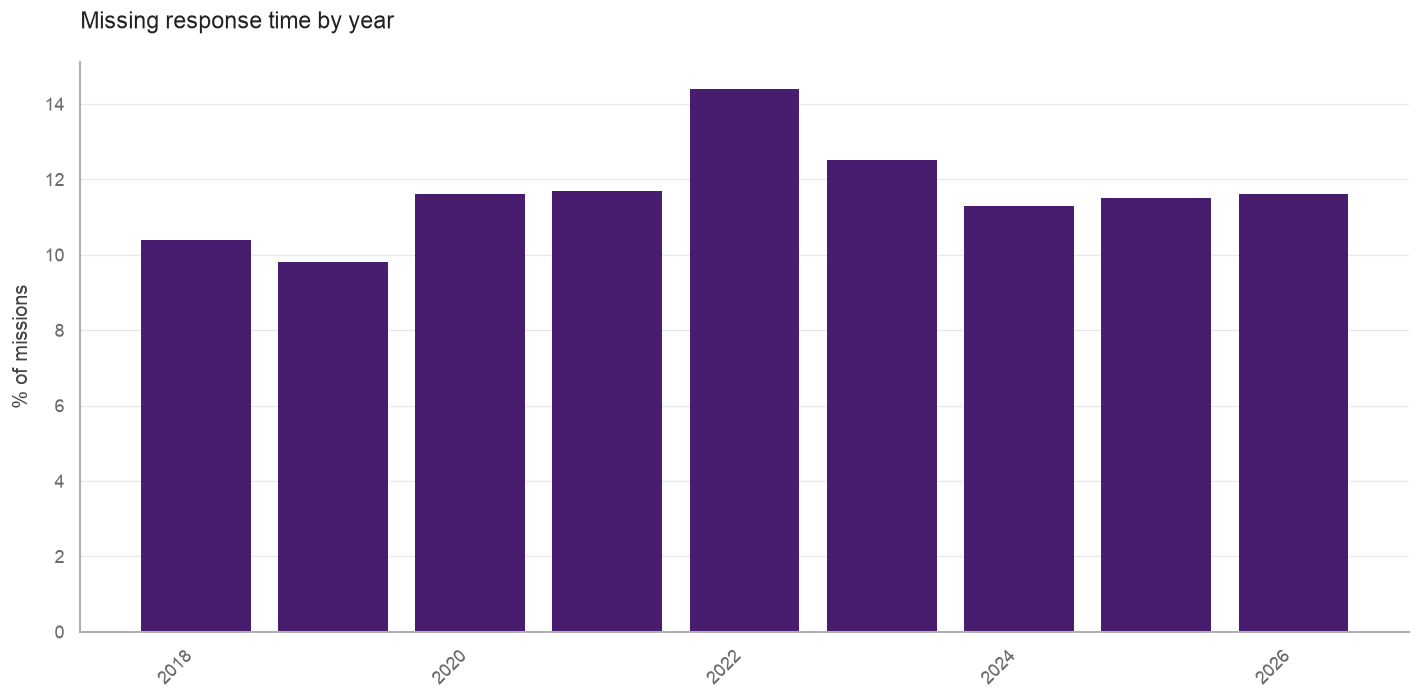

In [6]:
df_miss_year = q("""
    select source_year as year, count(*) as missions,
           round(100.0 * count(*) filter (where response_time_seconds is null) / count(*), 1) as pct_missing
    from stg_missions group by 1 order by 1
""")
show_df(df_miss_year)
fig, ax = bar(df_miss_year, x='year', y='pct_missing', title='Missing response time by year', ylabel='% of missions')

In [7]:
df_miss_type = q("""
    select mission_type, count(*) as missions,
           round(100.0 * count(*) filter (where response_time_seconds is null) / count(*), 1) as pct_missing
    from stg_missions group by 1 order by 2 desc
""")
show_df(df_miss_type)

,mission_type,missions,pct_missing
0,Rettungsdienst,3820978,8.60%
1,Rettungsdienst mit Technischer Hilfeleistung,210238,34.60%
2,Technische Hilfeleistung,164715,26.80%
3,Brand,160499,31.90%
4,Notverlegung,99687,21.80%
5,Pandemie,3903,16.40%
6,Sonstige,1153,54.80%
7,Befristete Ausserdienstnahme,29,65.50%


In [8]:
df_miss_tier = q("""
    select coalesce(dispatch_criticality, 'none') as tier, count(*) as missions,
           round(100.0 * count(*) filter (where response_time_seconds is null) / count(*), 1) as pct_missing
    from stg_missions where mission_type like 'Rettungsdienst%' group by 1 order by 1
""")
show_df(df_miss_tier)

,tier,missions,pct_missing
0,A,707949,5.00%
1,B,975120,7.60%
2,C,1152561,7.20%
3,D,869939,19.70%
4,E,41973,22.20%
5,O,14732,6.30%
6,none,268942,10.70%


## Duplicates

Einsätze haben keine ID. Identische Zeilen können zwei echte Einsätze sein (gleicher Tag, Bezirk, Typ, Zeit) oder ein Doppeleintrag. Wir messen nur, wie häufig identische Zeilen vorkommen.

In [9]:
df_dup = q("""
    with g as (
        select source_year, count(*) as n from stg_missions group by source_year, mission_date, mission_type, dispatchcode, dispatch_criticality,
            district_name, response_time_seconds, units_organisations, units_first_type, units_non_berlin_involved, units_several_involved,
            units_reinforcements_called, firstresponder_alarmed, firstresponder_indication, firstresponder_first_arrival, emergency_doctor_involved
    )
    select source_year as year, sum(n) as missions, sum(n) - count(*) as rows_in_identical_groups,
           round(100.0 * (sum(n) - count(*)) / sum(n), 1) as pct_identical
    from g group by 1 order by 1
""")
show_df(df_dup)

,year,missions,rows_in_identical_groups,pct_identical
0,2018,463684.00,2148.00,0.50%
1,2019,472638.00,2326.00,0.50%
2,2020,466774.00,2439.00,0.50%
3,2021,489860.00,2023.00,0.40%
4,2022,526743.00,5107.00,1.00%
5,2023,512885.00,3664.00,0.70%
6,2024,532575.00,2469.00,0.50%
7,2025,556864.00,3302.00,0.60%
8,2026,439179.00,1913.00,0.40%


In [10]:
_ = inspect_duplicates(df_eda)


───  DUPLICATES  ─────────────────────────────────────────────


,metric,count,pct
0,total rows,200000,
1,duplicates,93,0.05%
2,unique rows,199907,99.95%


Duplicate rows returned — use result.head(10) to inspect.


## Categories

### Mission Type

In [11]:
df_type_year = q("""
    select mission_type, source_year as year, count(*) as n from stg_missions group by 1, 2
""").pivot(index='mission_type', columns='year', values='n').fillna(0).astype(int)
show_df(df_type_year.reset_index())

year,mission_type,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Befristete Ausserdienstnahme,0,0,0,0,0,0,0,3,26
1,Brand,15027,15852,15867,16397,18710,18822,20645,21623,17556
2,Notverlegung,593,7022,14034,16158,14325,13365,12700,12415,9075
3,Pandemie,0,0,3903,0,0,0,0,0,0
4,Rettungsdienst,410807,408333,395600,416154,447409,437418,454450,475193,375614
5,Rettungsdienst mit Technischer Hilfeleistung,20495,23444,21575,22717,24880,24137,25637,26750,20603
6,Sonstige,163,102,111,78,51,54,111,200,283
7,Technische Hilfeleistung,16599,17885,15684,18356,21368,19089,19032,20680,16022


### Dispatch Level

Die Stufe (`dispatch_criticality`: A bis E, O) ist unsere Näherung für "kritisch" (Annahme, nicht belegt). Ändert sich ihre Verteilung über die Jahre, ändert sich die Messung selbst.

tier,year,A,B,C,D,E,O,none
0,2018,23.60,18.50,20.40,15.80,1.00,0.50,20.30
1,2019,23.10,18.90,21.50,16.30,1.00,0.50,18.60
2,2020,20.80,21.40,24.10,19.30,1.20,0.30,13.00
3,2021,21.00,25.90,27.10,21.70,1.10,0.20,3.00
4,2022,16.90,27.60,29.90,21.80,1.10,0.20,2.60
5,2023,13.50,26.70,33.10,22.70,1.20,0.70,2.10
6,2024,13.40,26.10,33.20,24.80,1.00,0.40,1.00
7,2025,13.60,25.90,33.40,25.10,1.00,0.30,0.70
8,2026,13.20,25.70,33.20,26.00,0.90,0.20,0.80


Text(0, 0.5, '% of EMS missions')

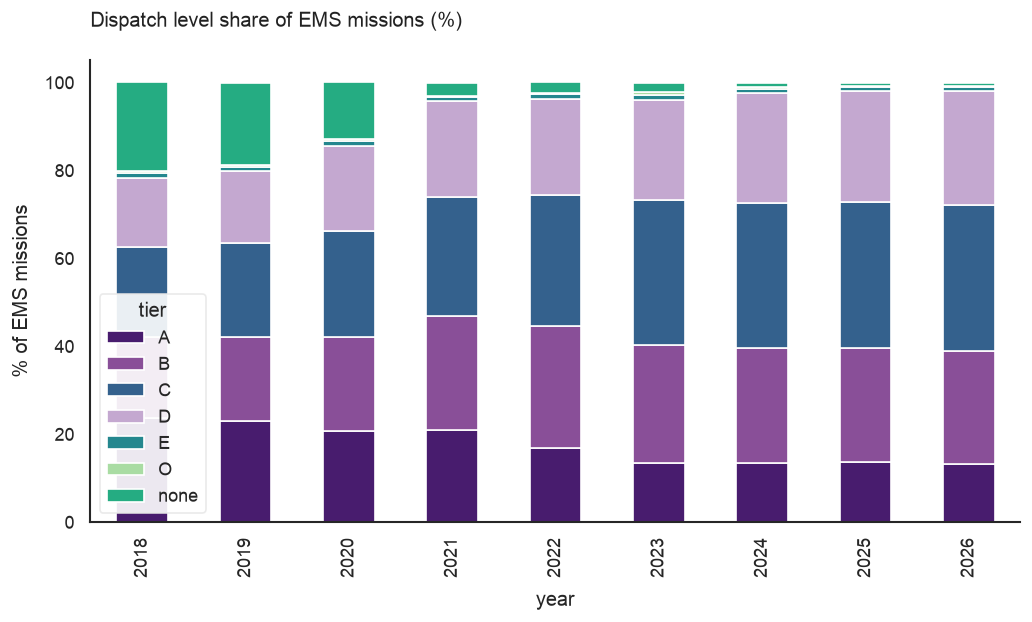

In [12]:
df_tier = q("""
    select source_year as year, coalesce(dispatch_criticality, 'none') as tier, count(*) as n
    from stg_missions where mission_type like 'Rettungsdienst%' group by 1, 2
""").pivot(index='year', columns='tier', values='n').fillna(0)
df_tier_share = (df_tier.div(df_tier.sum(axis=1), axis=0) * 100).round(1)
show_df(df_tier_share.reset_index())
ax = df_tier_share.plot(kind='bar', stacked=True, figsize=(10, 5), title='Dispatch level share of EMS missions (%)')
ax.set_xlabel('year'); ax.set_ylabel('% of EMS missions')

### Dispatch Codes

In [13]:
df_codes = q("""
    select m.dispatchcode, coalesce(c.dispatchcode_name, '(no name)') as name, count(*) as n
    from stg_missions m left join seed_dispatch_codes c using (dispatchcode)
    where m.dispatchcode is not null group by 1, 2 order by n desc limit 15
""")
show_df(df_codes)
df_code_cov = q("""
    select source_year as year, round(100.0 * count(dispatchcode) / count(*), 1) as pct_with_code
    from stg_missions where mission_type like 'Rettungsdienst%' group by 1 order by 1
""")
show_df(df_code_cov)

,dispatchcode,name,n
0,17,Sturz / Absturz,522569
1,26,Kranke Person (Spezielle Krankheitsbilder),370287
2,31,Bewusstlosigkeit / Ohnmacht (Beinahe-),350332
3,06,Atembeschwerden,339608
4,30,Verletzungen,212596
5,10,Brustschmerzen / Andere Beschwerden in der Brust (Nicht Traumatisch),210936
6,01,"Bauchschmerzen,-beschwerden",200628
7,19,Herzbeschwerden / Implantierter Defibrillator,184881
8,25,Psychiatrie / Abnormales Verhalten / Suizidversuch,184592
9,23,Überdosis / Vergiftung (Einnahme),161559


,year,pct_with_code
0,2018,79.70%
1,2019,81.40%
2,2020,87.00%
3,2021,97.00%
4,2022,97.40%
5,2023,97.90%
6,2024,99.00%
7,2025,99.30%
8,2026,99.20%


### District

In [14]:
df_district = q("""
    select district_name, count(*) as missions,
           round(median(response_time_seconds), 0) as median_response_s
    from stg_missions group by 1 order by 2 desc
""")
show_df(df_district)

,district_name,missions,median_response_s
0,Mitte,575755,581.00
1,Charlottenburg-Wilmersdorf,426362,581.00
2,Neukölln,393697,607.00
3,Tempelhof-Schöneberg,392803,589.00
4,Pankow,384690,628.00
5,Friedrichshain-Kreuzberg,353464,550.00
6,Lichtenberg,344441,650.00
7,Reinickendorf,329019,642.00
8,Treptow-Köpenick,325957,656.00
9,Marzahn-Hellersdorf,314161,651.00


### Units and Resources

In [15]:
df_units = q("""
    select coalesce(units_first_type, '(none)') as first_unit, count(*) as n,
           round(median(response_time_seconds), 0) as median_response_s
    from stg_missions group by 1 order by n desc limit 12
""")
show_df(df_units)
bool_cols = ['units_non_berlin_involved', 'units_several_involved', 'units_reinforcements_called',
             'firstresponder_alarmed', 'firstresponder_indication', 'firstresponder_first_arrival', 'emergency_doctor_involved']
df_bool = pd.DataFrame({c: q(f'select round(100.0 * avg(cast({c} as int)), 1) as p from stg_missions')['p'] for c in bool_cols}).T
df_bool.columns = ['pct_true']
show_df(df_bool.reset_index().rename(columns={'index': 'flag'}))

,first_unit,n,median_response_s
0,RTW,1115803,613.00
1,RTW-C,1062866,609.00
2,RTW-B,527028,736.00
3,NEF,327853,565.00
4,LHF,194284,577.00
5,RTW-JUH,170500,569.00
6,LHF-M,166854,583.00
7,RTW-DRK,159180,540.00
8,RTW-ASB,142774,601.00
9,RTW`,131526,591.00


,flag,pct_true
0,units_non_berlin_involved,0.20%
1,units_several_involved,33.00%
2,units_reinforcements_called,5.10%
3,firstresponder_alarmed,1.60%
4,firstresponder_indication,25.10%
5,firstresponder_first_arrival,1.10%
6,emergency_doctor_involved,23.50%


## Response Time

### Distribution


───  NUMERIC STATS  ──────────────────────────────────────────


,column,missing_pct,count,mean,median,std,min,25%,75%,max,mean_median_diff,skewness
0,response_time_seconds,11.69%,176611.00,662.74,611.00,249.87,123.00,499.00,765.00,1919.00,51.74,1.50



───  OUTLIERS  ───────────────────────────────────────────────


,column,mean,median,mean_med_diff,lower_1.5x,upper_1.5x,outliers_1.5x,outliers_1.5x_%,lower_3x,upper_3x,outliers_3x,outliers_3x_%
0,response_time_seconds,662.74,611.00,51.74,100.00,1164.00,8280,4.69%,-299.00,1563.00,1865,1.06%


→ inspect_outlier_detail(df, col) for boxplot+histogram per feature.


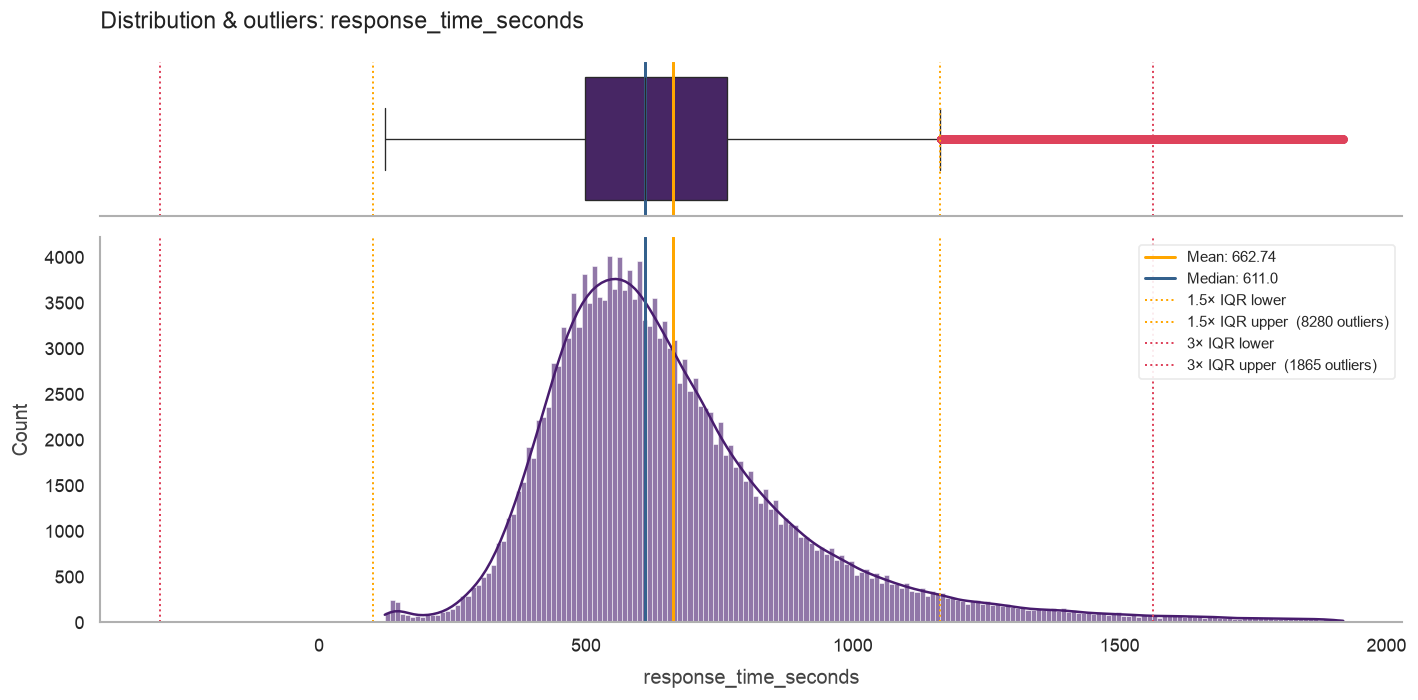

In [16]:
inspect(df_eda, sections=['numeric', 'outliers'], columns=['response_time_seconds'])
inspect_outlier_detail(df_eda.dropna(subset=['response_time_seconds']), 'response_time_seconds')

### By Year and Type

,year,median_s,p90_s,n
0,2018,584.00,897.00,391090
1,2019,577.00,883.00,395800
2,2020,598.00,932.00,375289
3,2021,617.00,989.00,394544
4,2022,637.00,1029.00,413731
5,2023,621.00,977.00,412258
6,2024,621.00,959.00,434586
7,2025,612.00,943.00,453812
8,2026,611.00,947.00,357303


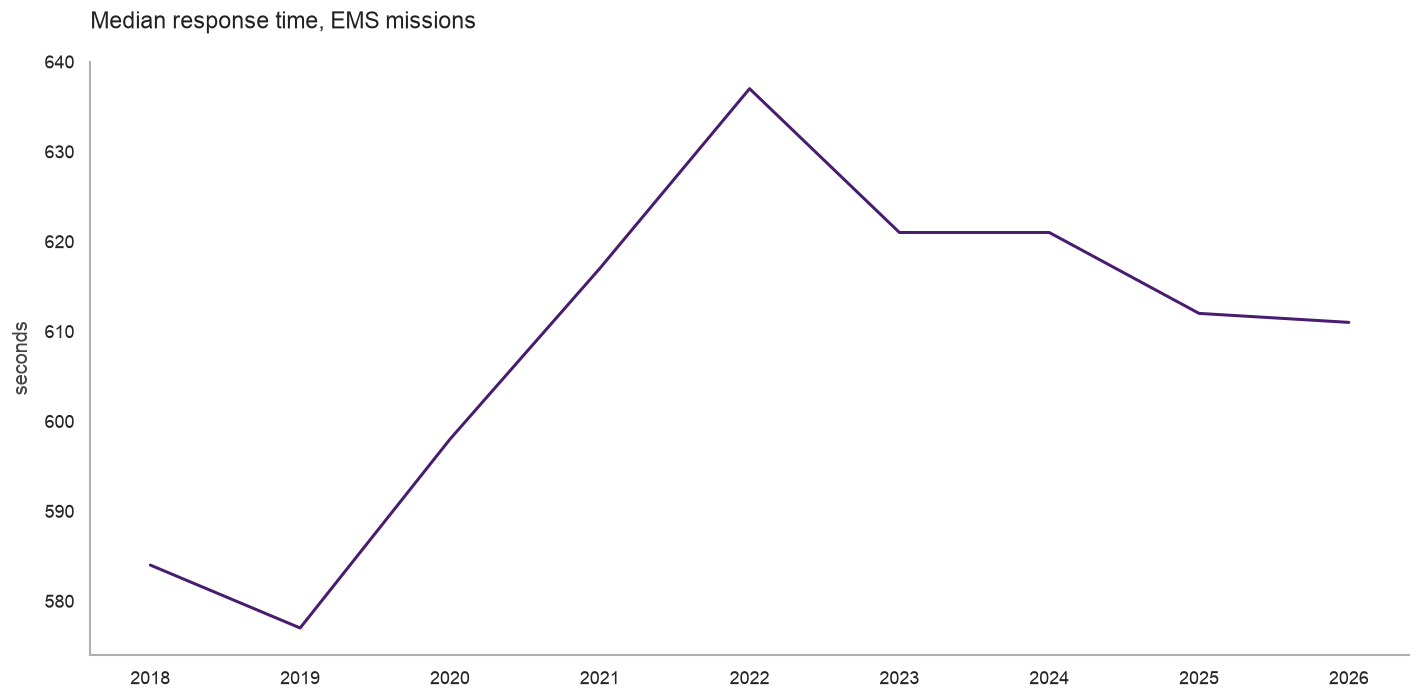

In [17]:
df_rt_year = q("""
    select source_year as year, round(median(response_time_seconds), 0) as median_s,
           round(quantile_cont(response_time_seconds, 0.9), 0) as p90_s, count(response_time_seconds) as n
    from stg_missions where mission_type like 'Rettungsdienst%' group by 1 order by 1
""")
show_df(df_rt_year)
fig, ax = line(df_rt_year, x='year', y='median_s', title='Median response time, EMS missions', ylabel='seconds')

In [18]:
df_rt_type = q("""
    select mission_type, round(median(response_time_seconds), 0) as median_s,
           round(quantile_cont(response_time_seconds, 0.9), 0) as p90_s, count(response_time_seconds) as n
    from stg_missions group by 1 order by n desc
""")
show_df(df_rt_type)

,mission_type,median_s,p90_s,n
0,Rettungsdienst,612.00,959.00,3490973
1,Rettungsdienst mit Technischer Hilfeleistung,536.00,722.00,137440
2,Technische Hilfeleistung,787.00,1444.00,120605
3,Brand,557.00,760.00,109227
4,Notverlegung,730.00,1448.00,77992
5,Pandemie,688.00,1101.00,3261
6,Sonstige,635.00,1421.00,521
7,Befristete Ausserdienstnahme,153.00,329.00,10


## Time

,weekday,missions,median_response_s
0,Monday,652059,616.00
1,Tuesday,635651,612.00
2,Wednesday,639895,614.00
3,Thursday,643464,617.00
4,Friday,646753,616.00
5,Saturday,635531,605.00
6,Sunday,607849,597.00


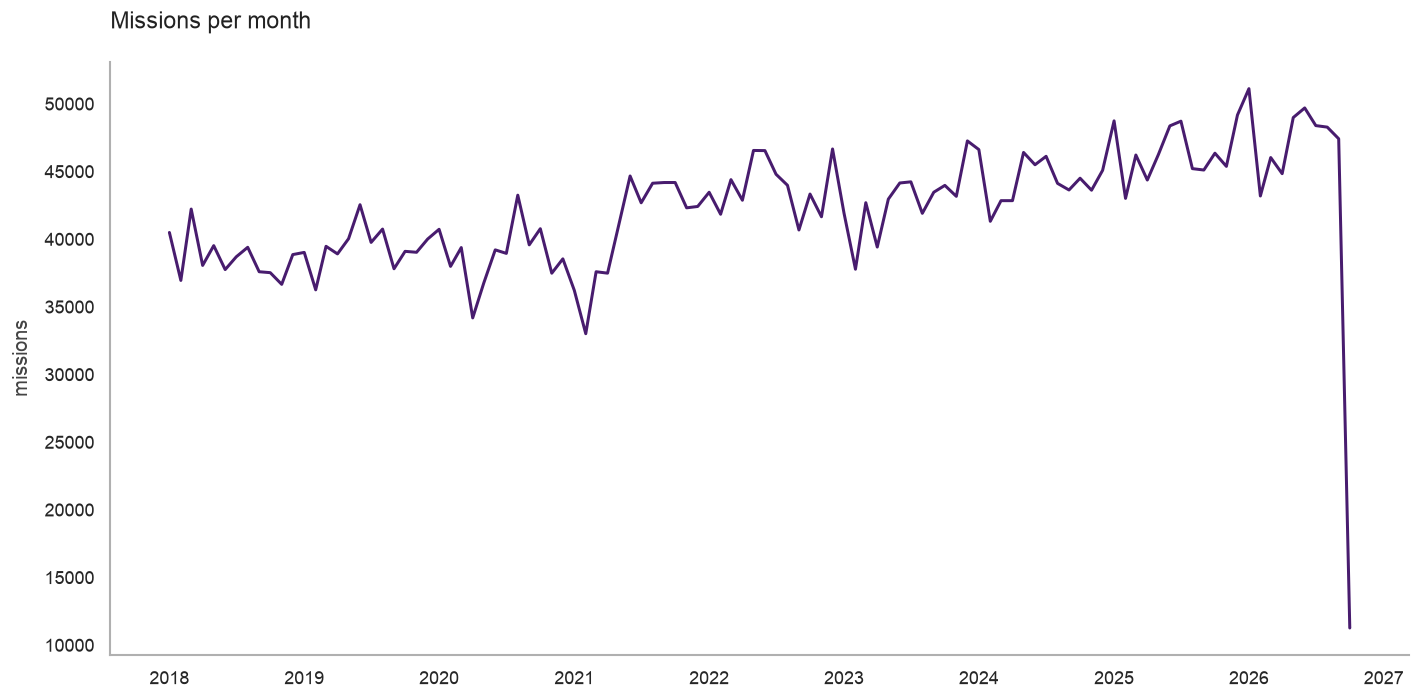

In [19]:
df_month = q("""
    select date_trunc('month', mission_date)::date as month, count(*) as missions
    from stg_missions group by 1 order by 1
""")
fig, ax = line(df_month, x='month', y='missions', title='Missions per month', ylabel='missions')
df_wd = q("""
    select dayname(mission_date) as weekday, isodow(mission_date) as dow, count(*) as missions,
           round(median(response_time_seconds), 0) as median_response_s
    from stg_missions group by 1, 2 order by 2
""")
show_df(df_wd.drop(columns='dow'))

## Findings

### Content

Einsatz-Einzeldatensatz der Berliner Feuerwehr: Tag (ohne Uhrzeit), Einsatztyp, Dispatch-Code und -Stufe, Bezirk, Antwortzeit in Sekunden, Einsatzmittel (`units_*`, erstes Fahrzeug, Organisationen), Notarzt, First Responder. Im Stand dieser Ausführung 2018-01-01 bis 2026-10-07; `stg_missions` hat genau so viele Zeilen wie die Rohtabelle.

### Usefulness

Einzige Quelle auf Einsatzebene. Sie trägt den Zeitverlauf (Jahr, Monat, Wochentag), den Bezirksvergleich und die Abhängigkeit von Einsatzart, Dringlichkeit und Einsatzmitteln. Ohne sie gäbe es keine eigene Antwortzeit-Analyse, nur die offiziellen Jahresquoten.

### Limits

* **Keine Uhrzeit, keine Koordinaten, keine ID.** Tageszeit-Effekte sind nicht prüfbar, "wo" bleibt auf 12 Bezirke begrenzt, identische Zeilen lassen sich nicht von Doppeleinträgen trennen.
* **Antwortzeit fehlt systematisch, nicht zufällig.** Insgesamt gut jeder zehnte Einsatz, bei den übrigen Einsatztypen gut ein Fünftel bis ein Drittel und bei den Stufen D/E rund 20 % gegenüber 5 bis 8 % bei A bis C. Anteile auf Basis der vorhandenen Zeiten können verzerrt sein.
* **Die Dispatch-Stufe ist über die Jahre nicht stabil.** Der Anteil ohne Code sinkt von rund 20 % (2018) auf rund 3 % (2021) und etwa 1 % (2024), die Anteile von A bis D verschieben sich deutlich (A von 24 % auf 13 %, D von 16 % auf 26 %). Ein Vergleich "kritischer" Einsätze über die Jahre misst teils die Verschlüsselung statt die Realität.
* **Einsatztypen ändern sich:** `Notverlegung` erscheint ab 2019 in größerem Umfang, `Pandemie` nur 2020, `Befristete Ausserdienstnahme` erst ab 2025.
* **Dateninhalt:** Der Wert `RTW` mit angehängtem Backtick in `units_first_type` ist ein Tippfehler in der Quelle und betrifft eine sechsstellige Zahl von Einsätzen. Der Dispatch-Code 53 hat keinen Namen.

### Observations

Stand der Ausführung, Daten bis 2026-10-07. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Identische Zeilen: 0,4 bis 1,0 % je Jahr, Spitze 2022 | Duplicates |
| Median der Antwortzeit (Rettungsdienst) steigt von 2018 bis 2022 und sinkt danach leicht; das 90. Perzentil folgt dem Muster | Response Time, By Year and Type |
| Bezirksmedian reicht von rund 550 s (Friedrichshain-Kreuzberg) bis rund 655 s (Treptow-Köpenick); Außenbezirke im Osten und Norden liegen oben. Einsatzmix nicht kontrolliert | District |
| Wochentag wirkt schwach: Wochenende etwas schneller als Wochentage | Time |
| Technische Hilfeleistung und Notverlegung haben deutlich längere Zeiten als Rettungsdienst, Brand und Rettungsdienst mit Technischer Hilfeleistung kürzere | By Year and Type |
| Rechtsschiefe Verteilung, wenige Werte über 1.500 s | Distribution |

### Open Questions

* **`02_preparation`:** Wie behandeln wir die Backtick-Variante in `units_first_type` (Cleaning in Staging oder Seed-Mapping)? Wie dokumentieren wir die Einsatztypen-Gruppen (`mission_group`) und `Pandemie`?
* **`03_analysis_time` (BACKLOG 16):** Wie viel vom Abfall der Näherung 2018 bis 2023 ist Zusammensetzung (Stufenverteilung, fehlende Codes) und wie viel echte Veränderung? Prüfen: Antwortzeit innerhalb fester Stufe und Einsatzcode über die Jahre.
* **`03_analysis_mission_type`:** Sind D/E tatsächlich die "kritischen" Einsätze? Vergleich mit der Regional-Quote; Einfluss der fehlenden Antwortzeiten (Sensitivität).
* **`03_analysis_geo`:** Bezirksunterschiede bereinigt um Einsatzmix und Stufe.
* **Duplikate (BACKLOG 4):** Ohne ID nicht lösbar; wir beziffern den möglichen Fehler (unter 1 %) und lassen die Zeilen drin.